# Feature Importance + Latent Manifold Assignment

**Goal:**
1. Train a baseline model on the original dataset and record metrics (Table 1).
2. Use feature importance to drop noisy/irrelevant features.
3. Enrich with a 3rd dataset + add 2-3 **latent variables (manifold)** from the domain.
4. Retrain and record new metrics (Table 2).
5. Compare Table 1 vs Table 2 to show progress.
6. Run a **Muller Loop** across regressors + a **Keras MLP**.

> Replace the sample dataset cells with your own datasets (1, 2, 3) from your project domain.

In [1]:
!pip -q install xgboost scikit-learn pandas numpy matplotlib seaborn tensorflow

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score,
                              precision_score, recall_score, f1_score, roc_auc_score, roc_curve)
from xgboost import XGBRegressor, XGBClassifier
import warnings; warnings.filterwarnings('ignore')
np.random.seed(42)

## 1. Load Dataset 1 (replace with your own)
Using California Housing as a stand-in. Add noisy features to simulate the cleanup gain.

In [3]:
data = fetch_california_housing(as_frame=True)
df = data.frame.copy()
df['target'] = df['MedHouseVal']; df = df.drop(columns=['MedHouseVal'])

# inject noise features to mimic a messy dataset
rng = np.random.RandomState(0)
for i in range(5):
    df[f'noise_{i}'] = rng.normal(size=len(df))
df['random_cat'] = rng.randint(0, 4, size=len(df))
print(df.shape); df.head()

(20640, 15)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target,noise_0,noise_1,noise_2,noise_3,noise_4,random_cat
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,1.764052,-0.787203,-0.307501,-0.918614,1.034878,1
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,0.400157,-0.960179,0.779337,-0.276920,1.965833,1
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,0.978738,1.557196,1.749710,-1.770633,0.377349,3
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,2.240893,-0.005167,0.103542,0.476396,1.406876,1
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,1.867558,1.601185,0.415656,1.535469,-2.771483,3


## 2. Baseline training (Dataset 1 only) — produces **Table 1**

In [4]:
def make_xy(frame):
    X = frame.drop(columns=['target']); y = frame['target']
    return X, y

def eval_classification(y_true, y_pred, y_prob):
    return dict(
        accuracy=accuracy_score(y_true, y_pred),
        precision=precision_score(y_true, y_pred),
        recall=recall_score(y_true, y_pred),
        f1=f1_score(y_true, y_pred),
        auc=roc_auc_score(y_true, y_prob),
    )

def run_classifier(frame, label):
    X, y = make_xy(frame)
    y_bin = (y > y.median()).astype(int)  # binary target for AUC/ROC
    Xtr, Xte, ytr, yte = train_test_split(X, y_bin, test_size=0.2, random_state=42)
    sc = StandardScaler(); Xtr_s = sc.fit_transform(Xtr); Xte_s = sc.transform(Xte)
    clf = XGBClassifier(n_estimators=200, max_depth=5, use_label_encoder=False, eval_metric='logloss')
    clf.fit(Xtr_s, ytr)
    yp = clf.predict(Xte_s); yprob = clf.predict_proba(Xte_s)[:,1]
    m = eval_classification(yte, yp, yprob); m['model'] = label
    return m, clf, X.columns

table1_metrics, base_model, base_cols = run_classifier(df, 'Baseline (Dataset 1 + noise)')
table1 = pd.DataFrame([table1_metrics])[['model','accuracy','precision','recall','f1','auc']]
print('=== TABLE 1: Baseline ===')
table1

=== TABLE 1: Baseline ===


,model,accuracy,precision,recall,f1,auc
0,Baseline (Dataset 1 + noise),0.899952,0.903448,0.894198,0.898799,0.963027


## 3. Feature Importance — drop noisy/irrelevant features

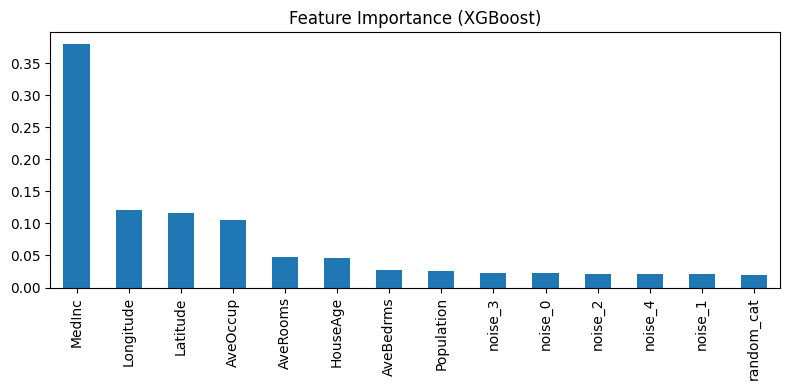

KEEP: ['MedInc', 'Longitude', 'Latitude', 'AveOccup']
DROP (noisy): ['AveRooms', 'HouseAge', 'AveBedrms', 'Population', 'noise_3', 'noise_0', 'noise_2', 'noise_4', 'noise_1', 'random_cat']


In [5]:
imp = pd.Series(base_model.feature_importances_, index=base_cols).sort_values(ascending=False)
plt.figure(figsize=(8,4)); imp.plot(kind='bar'); plt.title('Feature Importance (XGBoost)'); plt.tight_layout(); plt.show()

# keep features above the mean importance
threshold = imp.mean()
keep = imp[imp >= threshold].index.tolist()
drop = imp[imp < threshold].index.tolist()
print('KEEP:', keep); print('DROP (noisy):', drop)
df_clean = df[keep + ['target']].copy()

## 4. Amalgamate Dataset 2 + Dataset 3 and add **latent manifold** variables

Pick 2-3 latent variables motivated by domain reading. Example for housing:
- **Neighborhood Desirability** = f(income, rooms, location)
- **Population Pressure** = f(population, occupancy)
- **Affordability Index** = f(income, rooms/household)

Replace this with your own latent variables from your domain articles.

In [6]:
# Stand-in 'Dataset 2' and 'Dataset 3' enrichments (replace with real scraped/joined data)
df_clean['ds2_school_score']    = df['MedInc'] * 0.6 + rng.normal(0, 0.2, len(df))
df_clean['ds3_crime_rate']      = 5 - df['MedInc'] * 0.3 + rng.normal(0, 0.3, len(df))

# Latent manifold variables
df_clean['LV_neighborhood_desirability'] = (
    df_clean['ds2_school_score'] - df_clean['ds3_crime_rate'] + df['MedInc']
)
df_clean['LV_population_pressure'] = df['Population'] / (df['AveOccup'] + 1)
df_clean['LV_affordability_index'] = df['MedInc'] / (df['AveRooms'] + 1)

print(df_clean.shape); df_clean.head()

(20640, 10)


,MedInc,Longitude,Latitude,AveOccup,target,ds2_school_score,ds3_crime_rate,LV_neighborhood_desirability,LV_population_pressure,LV_affordability_index
0,8.3252,-122.23,37.88,2.555556,4.526,4.865170,2.349715,10.840656,90.562500,1.042719
1,8.3014,-122.22,37.86,2.109842,3.585,4.905873,1.959424,11.247850,772.064990,1.146897
2,7.2574,-122.24,37.85,2.802260,3.521,4.708990,2.450225,9.516165,130.448737,0.781362
3,5.6431,-122.25,37.85,2.547945,3.413,3.297067,2.749447,6.190720,157.274131,0.827755
4,3.8462,-122.25,37.85,2.181467,3.422,2.250140,3.463974,2.632366,177.591019,0.528190


## 5. Retrain on cleaned + enriched + latent dataset — produces **Table 2**

In [7]:
table2_metrics, new_model, new_cols = run_classifier(df_clean, 'After FI + Enrichment + Latent Manifold')
table2 = pd.DataFrame([table2_metrics])[['model','accuracy','precision','recall','f1','auc']]
print('=== TABLE 2: After Feature Importance + Latent Variables ==='); table2

=== TABLE 2: After Feature Importance + Latent Variables ===


,model,accuracy,precision,recall,f1,auc
0,After FI + Enrichment + Latent Manifold,0.899467,0.89786,0.900049,0.898953,0.964395


## 6. Side-by-side comparison (Table 1 vs Table 2)

In [8]:
comparison = pd.concat([table1, table2], ignore_index=True)
print('=== COMPARISON ===')
comparison

=== COMPARISON ===


,model,accuracy,precision,recall,f1,auc
0,Baseline (Dataset 1 + noise),0.899952,0.903448,0.894198,0.898799,0.963027
1,After FI + Enrichment + Latent Manifold,0.899467,0.897860,0.900049,0.898953,0.964395


## 7. Muller Loop — multiple regressors on the enriched dataset

In [10]:
X, y = make_xy(df_clean)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
sc = StandardScaler(); Xtr_s = sc.fit_transform(Xtr); Xte_s = sc.transform(Xte)

models = {
    'LinearRegression':        LinearRegression(),
    'RandomForestRegressor':   RandomForestRegressor(n_estimators=200, random_state=42),
    'KNNRegressor':            KNeighborsRegressor(n_neighbors=7),
    'XGBRegressor':            XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05),
    'MLPRegressor':            MLPRegressor(hidden_layer_sizes=(64,32), max_iter=300, random_state=42),
}
rows = []
for name, m in models.items():
    m.fit(Xtr_s, ytr); yp = m.predict(Xte_s)
    rows.append(dict(model=name, RMSE=np.sqrt(mean_squared_error(yte, yp)), R2=r2_score(yte, yp)))
muller = pd.DataFrame(rows).sort_values('R2', ascending=False); muller

,model,RMSE,R2
3,XGBRegressor,0.497351,0.811236
1,RandomForestRegressor,0.525187,0.789515
4,MLPRegressor,0.539287,0.778061
2,KNNRegressor,0.703383,0.622447
0,LinearRegression,0.746634,0.574589


## 8. Keras MLP Neural Network

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Keras MLP -> RMSE: 0.5697393268452073  R2: 0.7522888610014115


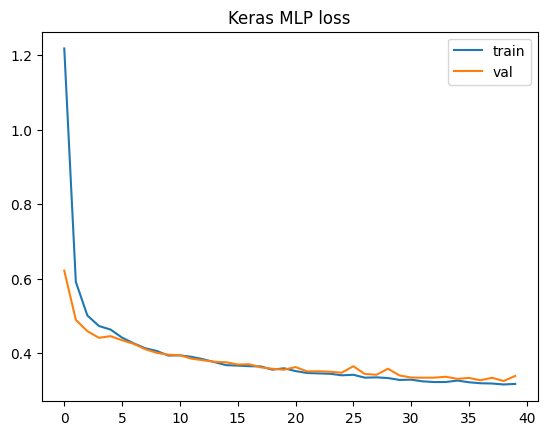

In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(64, activation='relu', input_shape=(Xtr_s.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
hist = model.fit(Xtr_s, ytr, validation_split=0.2, epochs=40, batch_size=64, verbose=0)
yp = model.predict(Xte_s).ravel()
print('Keras MLP -> RMSE:', np.sqrt(mean_squared_error(yte, yp)), ' R2:', r2_score(yte, yp))

plt.plot(hist.history['loss'], label='train'); plt.plot(hist.history['val_loss'], label='val')
plt.legend(); plt.title('Keras MLP loss'); plt.show()

## 9. ROC curve (Table 2 model)

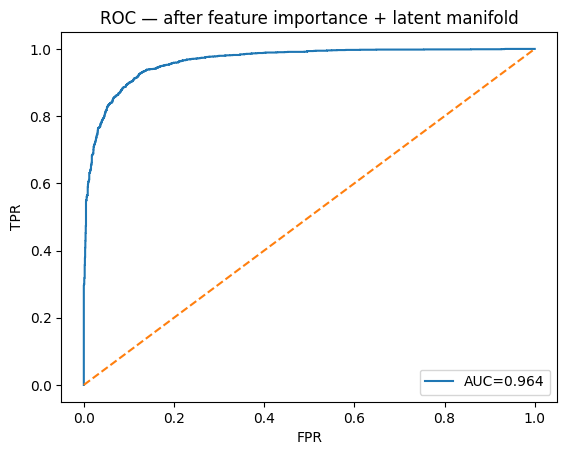

In [13]:
X, y = make_xy(df_clean); y_bin = (y > y.median()).astype(int)
Xtr, Xte, ytr, yte = train_test_split(X, y_bin, test_size=0.2, random_state=42)
sc = StandardScaler(); Xtr_s = sc.fit_transform(Xtr); Xte_s = sc.transform(Xte)
clf = XGBClassifier(n_estimators=200, max_depth=5, use_label_encoder=False, eval_metric='logloss').fit(Xtr_s, ytr)
yprob = clf.predict_proba(Xte_s)[:,1]
fpr, tpr, _ = roc_curve(yte, yprob)
plt.plot(fpr, tpr, label=f'AUC={roc_auc_score(yte, yprob):.3f}'); plt.plot([0,1],[0,1],'--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC — after feature importance + latent manifold'); plt.legend(); plt.show()

## 10. Write-up

- **Latent manifold:** describe the 2-3 latent variables you constructed and cite the domain articles (1/teammate).
- **3rd dataset:** state the source and scraping/joining method (Scrapy / BeautifulSoup / API / computed).
- **Interpretability gain:** explain how the latent variables make the model more understandable (e.g., 'desirability' is a single human-readable axis instead of 5 raw columns).
- **Business value:** tie the improvement in Table 2 vs Table 1 to a business outcome (better targeting, lower error, fewer features to collect).